#Importação de Bibliotecas

In [16]:
import pandas as pd
import io
import torch
import matplotlib.pyplot as plt
import numpy as np

# Carregando o dataset

Dataset: [https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression](https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression)

In [17]:
!curl -L -o /content/sample_data/salary-dataset-simple-linear-regression.zip\
  https://www.kaggle.com/api/v1/datasets/download/abhishek14398/salary-dataset-simple-linear-regression

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   457  100   457    0     0    381      0  0:00:01  0:00:01 --:--:--     0


### Removendo o arquivo do .zip

In [18]:
!unzip /content/sample_data/salary-dataset-simple-linear-regression.zip -d /content/

Archive:  /content/sample_data/salary-dataset-simple-linear-regression.zip
replace /content/Salary_dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/Salary_dataset.csv  


### Lendo o arquivo CSV

In [19]:
df = pd.read_csv('/content/Salary_dataset.csv')
display(df.head())

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


## Normalizando o Dataset

In [20]:
x = df['YearsExperience']
y = df['Salary']
salary_pd = pd.DataFrame()
salary_pd['x'] = x
salary_pd['y'] = y
salary_pd.head()

,x,y
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [21]:
x_norm = x - x.min()
x_norm /= x_norm.max()    # normalização
y_norm = y - y.min()
y_norm /= y_norm.max()

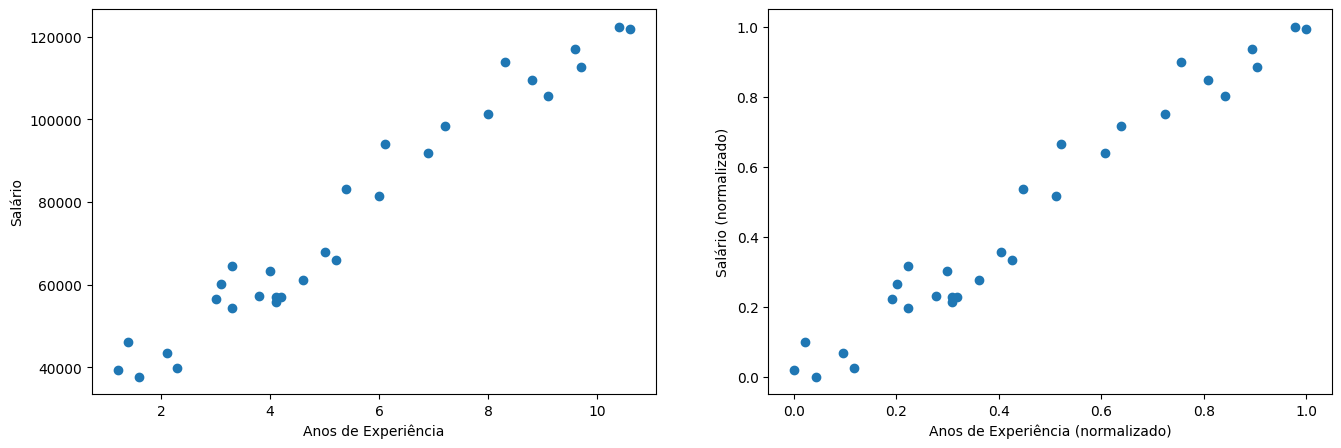

In [22]:
fig = plt.figure(figsize=(16,5))
ax_in = fig.add_subplot(1,2,1)
ax_in.scatter(x, y)
ax_in.set_xlabel('Anos de Experiência')
ax_in.set_ylabel('Salário')
ax_n = fig.add_subplot(1,2,2)
ax_n.scatter(x_norm, y_norm)
ax_n.set_xlabel('Anos de Experiência (normalizado)')
ax_n.set_ylabel('Salário (normalizado)');

### Criando a rede neural

In [23]:
model = torch.nn.Linear(1, 1)

### Instanciando a função de perda (MSE)

In [24]:
criterion = torch.nn.MSELoss()

ou

In [25]:
def compute_cost(X, y, wT):
    '''
    Compute cost for linear regression
    (X,y): amostras rotuladas X(n_samples,2) e y(n_samples,)
    wT: vetor coluna de parâmetros (já transposto)
       aceita tanto shape (2,1) Para um caso como (2,n_history) para n_history casos
    '''
    e = X.dot(wT) - y
    J = (e * e).mean(axis=0)
    return J

### Hiperparâmetros de Treinamento

In [26]:
learning_rate = 0.2
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
num_epocas = 100

## Laço de Treinamento

In [27]:
cost = 0
samp = 0
losses = []
w_history = np.zeros((num_epocas + 1, 2), np.float32)

# Convert pandas Series to PyTorch Tensors
x_tensor = torch.tensor(x_norm.values, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(y_norm.values, dtype=torch.float32).unsqueeze(1)

for epoca in range(num_epocas):
  optimizer.zero_grad()
  y_chapeu = model(x_tensor)
  loss = criterion(y_chapeu, y_tensor)
  loss.backward()
  optimizer.step()

  cost += loss.data
  samp += 1
  losses.append(cost / samp)
  w, b = [ww.data for ww in model.parameters()]
  w_history[epoca + 1, 0] = b[0]
  w_history[epoca + 1, 1] = w[0, 0]

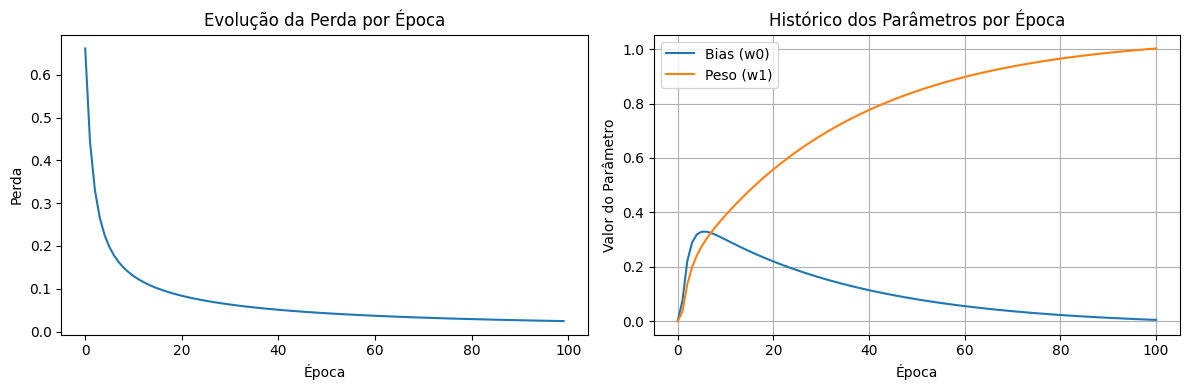

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss evolution
ax1.plot(losses)
ax1.set_xlabel('Época')
ax1.set_ylabel('Perda')
ax1.set_title('Evolução da Perda por Época')

# Plot weight history
ax2.plot(w_history[:, 0], label='Bias (w0)')
ax2.plot(w_history[:, 1], label='Peso (w1)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Valor do Parâmetro')
ax2.set_title('Histórico dos Parâmetros por Época')
ax2.legend()
ax2.grid(True)


plt.tight_layout()
plt.show()

## Avaliação

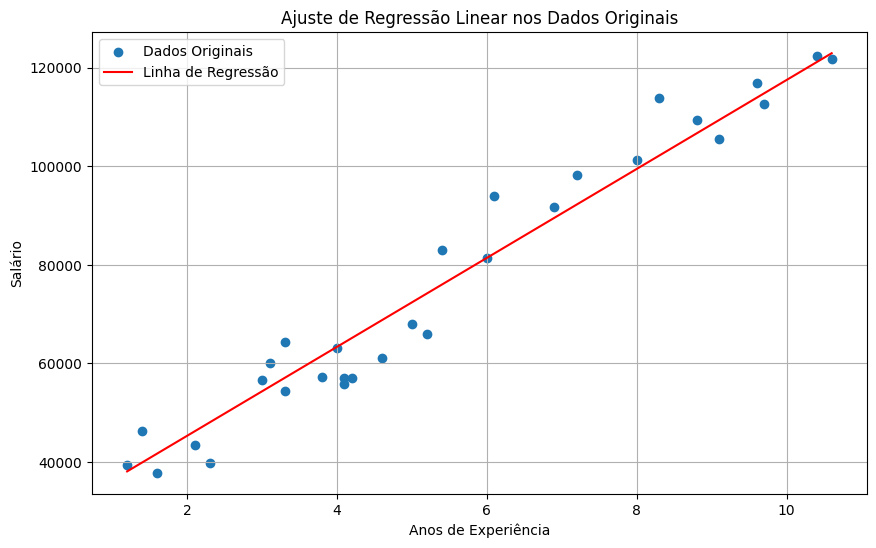

In [30]:
# Obter os pesos finais e bias treinados
w, b = [param.data for param in model.parameters()]
w = w.item()
b = b.item()

# O modelo foi treinado em dados normalizados, então os pesos são para dados normalizados.
# Para plotar a linha na escala de dados original, precisamos converter os pesos normalizados
# de volta para a escala original.

# Relembre os passos de normalização:
# x_norm = (x - x.min()) / (x.max() - x.min())
# y_norm = (y - y.min()) / (y.max() - y.min())
# O modelo prevê y_norm_chapeu = w * x_norm + b
# Queremos encontrar a relação entre y_chapeu e x

# Substitua as fórmulas de normalização na equação do modelo:
# (y_chapeu - y.min()) / (y.max() - y.min()) = w * ((x - x.min()) / (x.max() - x.min())) + b

# Reorganize para resolver para y_chapeu:
# y_chapeu - y.min() = w * (x - x.min()) * (y.max() - y.min()) / (x.max() - x.min()) + b * (y.max() - y.min())
# y_chapeu = w * (y.max() - y.min()) / (x.max() - x.min()) * (x - x.min()) + b * (y.max() - y.min()) + y.min()

# Seja W_original = w * (y.max() - y.min()) / (x.max() - x.min())
# Seja B_original = -w * (y.max() - y.min()) / (x.max() - x.min()) * x.min() + b * (y.max() - y.min()) + y.min()
# Então, y_chapeu = W_original * x + B_original

W_original = w * (y.max() - y.min()) / (x.max() - x.min())
B_original = -W_original * x.min() + b * (y.max() - y.min()) + y.min()


# Gerar pontos para a linha de regressão usando os valores originais de x
x_line = np.linspace(x.min(), x.max(), 100)
y_line = W_original * x_line + B_original

# Plotar dados originais e a linha de regressão
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Dados Originais')
plt.plot(x_line, y_line, color='red', label='Linha de Regressão')
plt.xlabel('Anos de Experiência')
plt.ylabel('Salário')
plt.title('Ajuste de Regressão Linear nos Dados Originais')
plt.legend()
plt.grid(True)
plt.show()

# Treinamento com Dataset de Treinamento e Validação

In [61]:
from sklearn.model_selection import train_test_split

# Dividir os dados normalizados em conjuntos de treinamento e validação (60% treinamento, 40% validação)
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_norm, y_norm, test_size=0.4, random_state=42)

print(f"Tamanho dos dados de treinamento: {x_train_split.shape[0]}")
print(f"Tamanho dos dados de validação: {x_val_split.shape[0]}")

Tamanho dos dados de treinamento: 18
Tamanho dos dados de validação: 12


In [62]:
# Definir um novo modelo para treinar nos dados divididos
model_split = torch.nn.Linear(1, 1)

# Instanciar a função de perda (MSE) e o otimizador para o novo modelo
criterion_split = torch.nn.MSELoss()
learning_rate_split = 0.2 # Pode ajustar a taxa de aprendizado se necessário
optimizer_split = torch.optim.SGD(params=model_split.parameters(), lr=learning_rate_split)

# Definir o número de épocas para treinamento
num_epocas_split = 100

In [63]:
# Converter os dados de treinamento normalizados para PyTorch Tensors
x_tensor_train = torch.tensor(x_train_split.values, dtype=torch.float32).unsqueeze(1)
y_tensor_train = torch.tensor(y_train_split.values, dtype=torch.float32).unsqueeze(1)

# Inicializar variáveis para acompanhar a perda e o histórico dos pesos durante o treinamento
cost_split = 0
samp_split = 0
losses_split = []
w_history_split = np.zeros((num_epocas_split + 1, 2), np.float32)

# Laço de Treinamento nos dados de treinamento
print("Iniciando o treinamento...")
for epoca_split in range(num_epocas_split):
  # Zerar os gradientes
  optimizer_split.zero_grad()

  # Forward pass: calcular a saída prevista (y_chapeu)
  y_chapeu_split = model_split(x_tensor_train)

  # Calcular a perda
  loss_split = criterion_split(y_chapeu_split, y_tensor_train)

  # Backward pass: calcular os gradientes
  loss_split.backward()

  # Atualizar os pesos
  optimizer_split.step()

  # Acompanhar a perda e o histórico dos pesos
  cost_split += loss_split.data
  samp_split += 1
  losses_split.append(cost_split / samp_split)
  # Armazenar o histórico dos pesos e bias
  w_split, b_split = [ww.data for ww in model_split.parameters()]
  w_history_split[epoca_split + 1, 0] = b_split[0]
  w_history_split[epoca_split + 1, 1] = w_split[0, 0]

print("Treinamento completo.")

Iniciando o treinamento...
Treinamento completo.


## Avaliação no Conjunto de Validação

In [67]:
# 1. Converter dados de validação normalizados para PyTorch Tensors
x_tensor_val = torch.tensor(x_val_split.values, dtype=torch.float32).unsqueeze(1)
y_tensor_val = torch.tensor(y_val_split.values, dtype=torch.float32).unsqueeze(1)

# 2. Definir o modelo para o modo de avaliação (desliga o cálculo de gradientes e dropout, se houver)
model_split.eval()

# 3. Fazer previsões no conjunto de validação sem calcular gradientes (para economizar memória e computação)
with torch.no_grad():
    y_chapeu_val = model_split(x_tensor_val)

# 4. Calcular a perda nos dados de validação
loss_val = criterion_split(y_chapeu_val, y_tensor_val)

# 5. Converter a perda de validação para um valor numérico Python
loss_val_item = loss_val.item()

# 6. Imprimir a perda de validação (MSE) e RMSE
print(f"Perda de Validação (MSE): {loss_val_item:.4f}")

Perda de Validação (MSE): 0.0052


## Visualizar resultados (Treinamento e Validação)

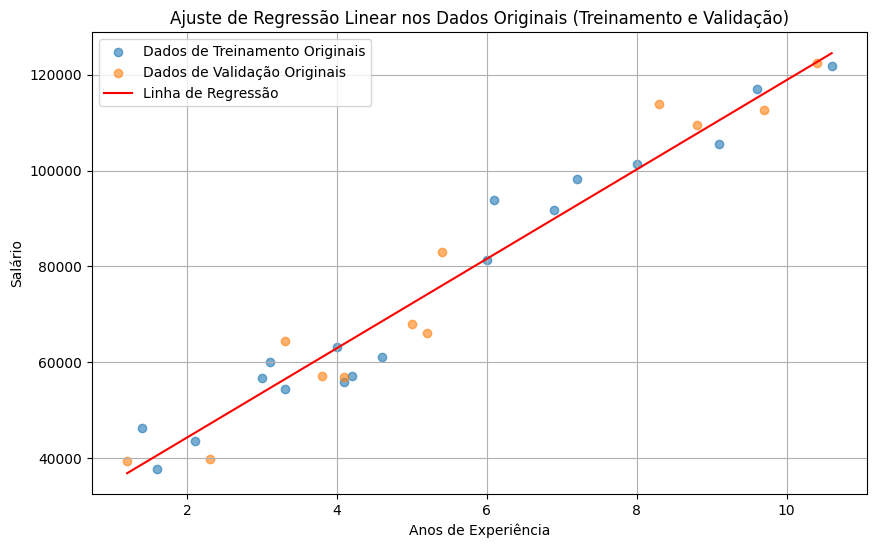

In [68]:
# 1. Obter os pesos finais e bias treinados do modelo (já feito na célula anterior)
w_split, b_split = [param.data for param in model_split.parameters()]
w_split = w_split.item()
b_split = b_split.item()

# 2. Converter os pesos e o bias para valores numéricos Python (já feito)

# 3. Calcular os pesos e o bias correspondentes na escala original
# y_norm = w_split * x_norm + b_split
# (y - y.min()) / (y.max() - y.min()) = w_split * (x - x.min()) / (x.max() - x.min()) + b_split
# y - y.min() = w_split * (x - x.min()) * (y.max() - y.min()) / (x.max() - x.min()) + b_split * (y.max() - y.min())
# y = w_split * (y.max() - y.min()) / (x.max() - x.min()) * (x - x.min()) + b_split * (y.max() - y.min()) + y.min()
# y = (w_split * (y.max() - y.min()) / (x.max() - y.min())) * x  - (w_split * (y.max() - y.min()) / (x.max() - x.min())) * x.min() + b_split * (y.max() - y.min()) + y.min()
# W_original = w_split * (y.max() - y.min()) / (x.max() - x.min())
# B_original = -W_original * x.min() + b_split * (y.max() - y.min()) + y.min()


W_original_split = w_split * (y.max() - y.min()) / (x.max() - x.min())
B_original_split = b_split * (y.max() - y.min()) + y.min() - W_original_split * x.min()


# 4. Gerar uma sequência de pontos (x_line_split) que abranja o intervalo original de "Anos de Experiência"
x_line_split = np.linspace(x.min(), x.max(), 100)

# 5. Calcular os valores de "Salário" correspondentes (y_line_split) usando a equação da reta com os pesos e bias na escala original
y_line_split = W_original_split * x_line_split + B_original_split

# 6. Crie um novo plot usando matplotlib.pyplot.
plt.figure(figsize=(10, 6))

# 7. Disperse os dados originais (não normalizados) de treinamento e validação no plot.
# Certifique-se de usar os dados x e y para obter os valores originais
# correspondentes aos índices dos conjuntos de treinamento e validação.
plt.scatter(x[x_train_split.index], y[y_train_split.index], label='Dados de Treinamento Originais', alpha=0.6)
plt.scatter(x[x_val_split.index], y[y_val_split.index], label='Dados de Validação Originais', alpha=0.6)


# 8. Plote a linha de regressão calculada
plt.plot(x_line_split, y_line_split, color='red', label='Linha de Regressão')

# 9. Adicione rótulos apropriados aos eixos x e y, um título para o plot e uma legenda.
plt.xlabel('Anos de Experiência')
plt.ylabel('Salário')
plt.title('Ajuste de Regressão Linear nos Dados Originais (Treinamento e Validação)')
plt.legend()
plt.grid(True)

# 10. Exiba o plot.
plt.show()